# Linear Regression

## Simple Linear Regression

A simple linear regression is one of the simplest (discriminative) Bayesian models - it’s just fitting a line to some data points! Suppose we have some data for which we have the $x$ values, and we want to predict the $y$ values:

In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

import probflow as pf

sns.set_theme()

I0000 00:00:1789865660.463428    3028 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789865660.463876    3028 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789865660.502766    3028 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789865661.376598    3028 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

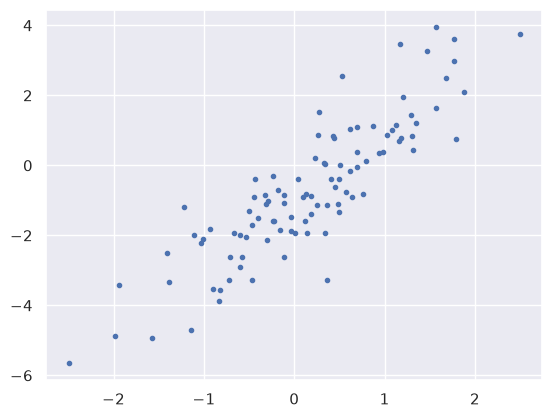

In [2]:
# Helper fn for generating data
randn = lambda *x: np.random.randn(*x).astype("float32")

# Generate some data
x = randn(100)
y = 2 * x - 1 + randn(100)

# Plot it
plt.plot(x, y, ".")
plt.show()

With a Bayesian regression, we predict the expected value using two parameters: the slope ($w$) and the intercept ($b$) of the fit line. Then, we model the datapoints as being drawn from a normal distribution (with standard deviation $\sigma$) centered at that expected value.

$$
y \sim \text{Normal}(wx + b, ~ \sigma)
$$

To create this model with ProbFlow, we’ll create a class which inherits from the `ContinuousModel` class (because our target variable is continuous). In the `__init__` method, we’ll define the parameters of the model. Then in the `__call__` method, we’ll use samples from those parameters to generate probabilistic predictions.

In [ ]:
class SimpleLinearRegression(pf.ContinuousModel):
    def __init__(self):
        self.w = pf.Parameter(name="Weight")
        self.b = pf.Parameter(name="Bias")
        self.s = pf.ScaleParameter(name="Std")

    def __call__(self, x):
        return pf.Normal(x * self.w() + self.b(), self.s())

After defining the model class, we just need to create an instance of the model, and then we can fit it to the data using stochastic variational inference!

In [4]:
model = SimpleLinearRegression()
model.fit(x, y, lr=0.8, epochs=500)

E0000 00:00:1789865661.609876    3028 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Now that we’ve fit the model, we can use it to make predictions on some test data:

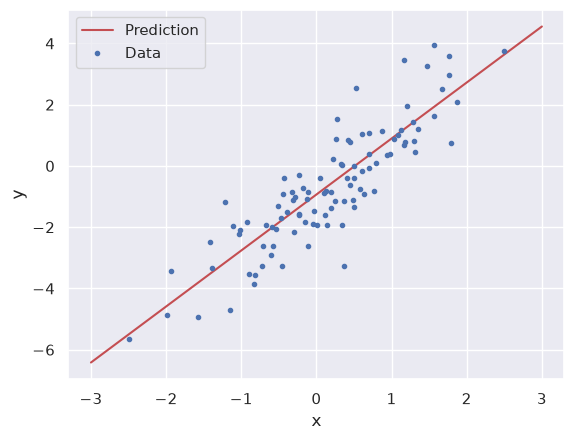

In [5]:
# Make predictions
x_test = np.array([-3, 3]).astype("float32")
preds = model.predict(x_test)

# Plot em
plt.plot(x_test, preds, "r", label="Prediction")
plt.plot(x, y, ".", label="Data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Or view the residuals of the model’s predictions (the difference between the actual and predicted values):

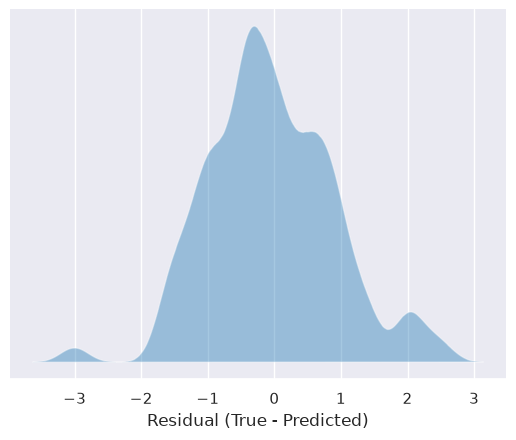

In [6]:
model.residuals_plot(x, y)

Since this is a probabilistic model, we can also look at the posterior distributions of our parameters (that is, the probability distributions over what the model thinks the true values of the parameters are):

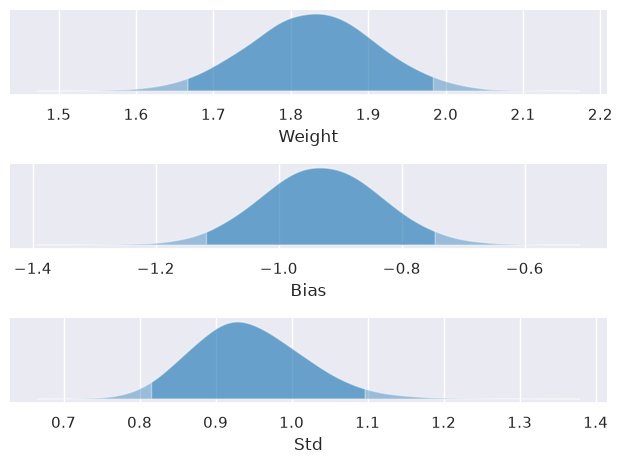

In [7]:
model.posterior_plot(ci=0.95)

We can also get the model’s confidence intervals on its predictions:

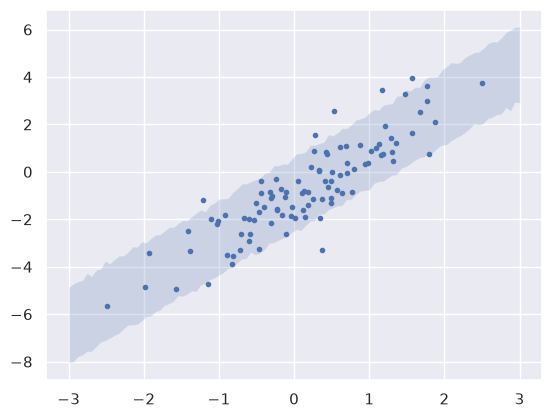

In [8]:
# Compute 95% predictive confidence intervals
x_eval = np.linspace(-3, 3, 100).astype("float32")
lb, ub = model.predictive_interval(x_eval, ci=0.9)

# Plot em
plt.fill_between(x_eval, lb, ub, alpha=0.2)
plt.plot(x, y, ".")

Or on just a single datapoint:

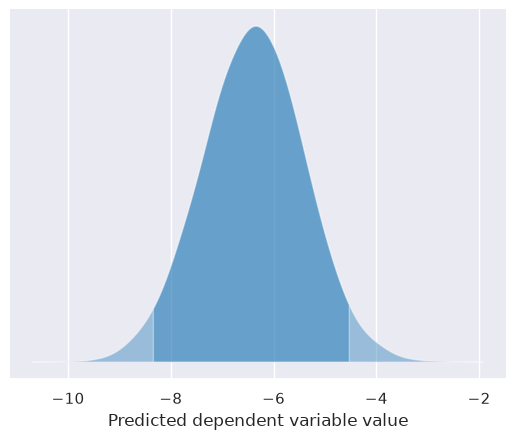

In [9]:
model.pred_dist_plot(x_eval[:1], ci=0.95)

Or draw sample predictions from the model:

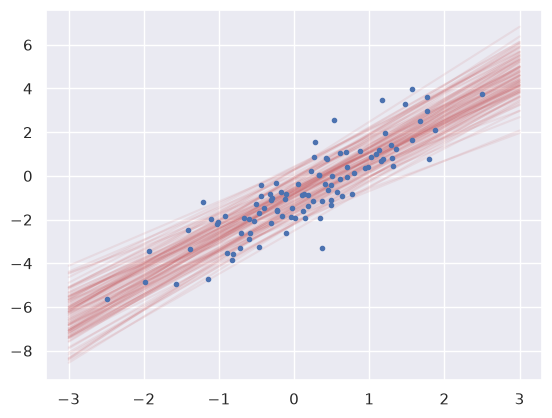

In [10]:
# Draw sample fits from the model
x_eval = np.array([-3, 3]).astype("float32")
samples = model.predictive_sample(x_eval, n=100)

# Plot em
x_plot = np.broadcast_to(x_eval[:, np.newaxis], samples.T.shape)
plt.plot(x_plot, samples.T, "r", alpha=0.1)
plt.plot(x, y, ".")

And view the Bayesian R-squared distribution:

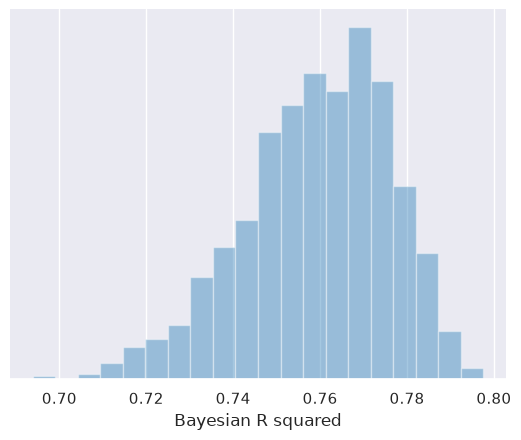

In [11]:
model.r_squared_plot(x, y)

## Multiple Linear Regression

A multiple linear regression is when we have multiple features (independent variables), and a single target (dependent variable). It’s just like a simple linear regression, except each feature gets its own weight:

$$
y \sim \text{Normal}(x_1 w_1 + x_2 w_2 + \dots + x_N w_N + b, ~ \sigma)
$$

or, if we represent the features and weights as vectors:

$$
y \sim \text{Normal}(\mathbf{x}^\top \mathbf{w} + b, ~ \sigma)
$$

Let’s generate a dataset with multiple features. Also, we’ll store the data in a Pandas DataFrame to see how ProbFlow works with Pandas.

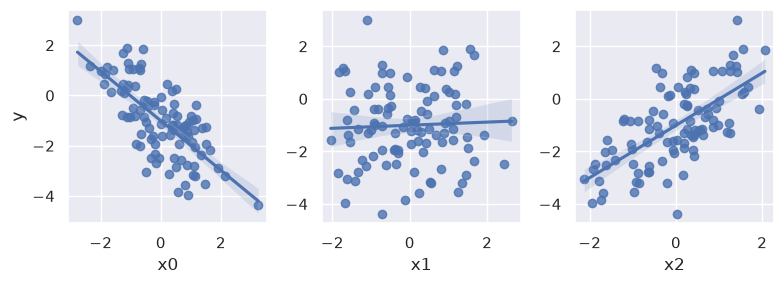

In [12]:
# Settings
D = 3  # number of dimensions
N = 100  # number of datapoints

# Generate some data
x = pd.DataFrame(randn(N, D))
weights = np.array([[-1.0], [0.1], [1.0]])
y = x @ weights - 1 + 0.2 * randn(N, 1)

# Plot em
plt.figure(figsize=(8, 3))
for i in range(D):
    plt.subplot(1, D, i + 1)
    sns.regplot(x=x[i], y=y[0])
    plt.xlabel(f"x{i}")
    if i == 0:
        plt.ylabel("y")
    else:
        plt.ylabel("")
plt.tight_layout()
plt.show()

We can create pretty much the same model as before, except we’ll create 𝐰 as a vector parameter, and because our input is now a pandas DataFrame, we’ll call df.values to get the underlying numpy array. Also note that below we’re using the @ operator, which is the [infix operator for matrix multiplication](https://www.python.org/dev/peps/pep-0465).

In [ ]:
class MultipleLinearRegression(pf.ContinuousModel):
    def __init__(self, dims):
        self.w = pf.Parameter([dims, 1], name="Weights")
        self.b = pf.Parameter(name="Bias")
        self.s = pf.ScaleParameter(name="Std")

    def __call__(self, x):
        return pf.Normal(x.values @ self.w() + self.b(), self.s())

Again, just instantiate the model and fit it to the data. You can control the learning rate and the number of epochs used to fit the data with the `lr` and `epochs` keyword arguments:

In [14]:
model = MultipleLinearRegression(3)
model.fit(x, y, lr=0.1, epochs=300)

/home/winsto99/code/probflow/src/probflow/models/model.py:257: UserWarning: Eager execution is being enabled because the input data is a pandas DataFrame or Series.
  warnings.warn(
E0000 00:00:1789865664.332823    3028 meta_optimizer.cc:967] function_optimizer failed: INVALID_ARGUMENT: Input 0 of node partitionedcall_10_RetVal was passed bool from PartitionedCall:13 incompatible with expected double.
E0000 00:00:1789865664.336857    3028 tfg_optimizer_hook.cc:135] tfg_optimizer{any(tfg-consolidate-attrs,tfg-toposort,tfg-shape-inference{graph-version=0},tfg-prepare-attrs-export)} failed: INVALID_ARGUMENT: Result #14 of node 'PartitionedCall' is out of bounds
	when importing GraphDef to MLIR module in GrapplerHook
E0000 00:00:1789865664.341566    3028 tfg_optimizer_hook.cc:135] tfg_optimizer{any(tfg-consolidate-attrs,tfg-functional-to-region,tfg.func(tfg-cf-sink),tfg-region-to-functional{force-control-capture=true},tfg-lift-legacy-call,symbol-privatize{},symbol-dce,tfg-prepare-attrs-exp

And again we can view the posterior distributions for our parameters, but this time our weight parameter is a vector with three elements, so each has an independent posterior:

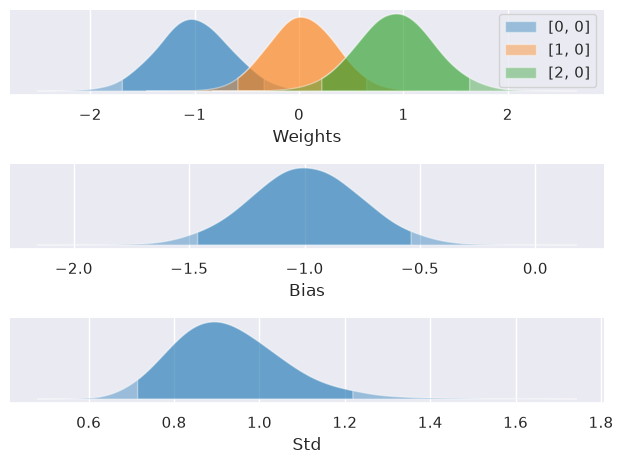

In [15]:
model.posterior_plot(ci=0.95)

## Using the Dense Module

The `Dense` module can also be used to build a linear regression:

In [ ]:
class LinearRegression(pf.ContinuousModel):
    def __init__(self, dims):
        self.layer = pf.Dense(dims, 1)
        self.s = pf.ScaleParameter()

    def __call__(self, x):
        return pf.Normal(self.layer(x.values), self.s())


# Fit it!
model = LinearRegression(3)
model.fit(x, y)

## Using the LinearRegression Model

But the easiest way to do a linear regression with ProbFlow is to use the pre-built LinearRegression model:

In [17]:
model = pf.LinearRegression(3)
model.fit(x, y)

E0000 00:00:1789865678.784881    3028 tfg_optimizer_hook.cc:135] tfg_optimizer{any(tfg-consolidate-attrs,tfg-toposort,tfg-shape-inference{graph-version=0},tfg-prepare-attrs-export)} failed: INVALID_ARGUMENT: Result #14 of node 'PartitionedCall' is out of bounds
	when importing GraphDef to MLIR module in GrapplerHook
E0000 00:00:1789865678.790613    3028 tfg_optimizer_hook.cc:135] tfg_optimizer{any(tfg-consolidate-attrs,tfg-functional-to-region,tfg.func(tfg-cf-sink),tfg-region-to-functional{force-control-capture=true},tfg-lift-legacy-call,symbol-privatize{},symbol-dce,tfg-prepare-attrs-export)} failed: INVALID_ARGUMENT: Result #14 of node 'PartitionedCall' is out of bounds
	when importing GraphDef to MLIR module in GrapplerHook
E0000 00:00:1789865678.790703    3028 tfg_optimizer_hook.cc:135] tfg_optimizer{any(tfg-consolidate-attrs,tfg-functional-to-region,tfg.func(tfg-cf-sink),tfg-region-to-functional{force-control-capture=true},tfg-lift-legacy-call,symbol-privatize{},symbol-dce,tfg-pre

## Using the MultivariateNormalParameter

So far, our parameters have been completely independent. We might want to model the full joint distribution, to allow for a potential correlation between the parameters. For that, we can use `MultivariateNormalParameter`, which creates a parameter that has a multivariate normal posterior, with full covariance. We’ll index the parameter in `__call__`, which automatically takes a slice from a sample of the parameter.

In [ ]:
class LinearRegression(pf.ContinuousModel):
    def __init__(self, dims):
        self.betas = pf.MultivariateNormalParameter(dims + 2)

    def __call__(self, x):
        w = self.betas[:-2]
        b = self.betas[-2]
        s = tf.nn.softplus(self.betas[-1])
        return pf.Normal(x.values @ w + b, s)

Then we can instantiate the model and fit it:

In [19]:
model = LinearRegression(3)
model.fit(x, y, lr=0.1, epochs=300)

Now the covariance between parameters has also been modeled:

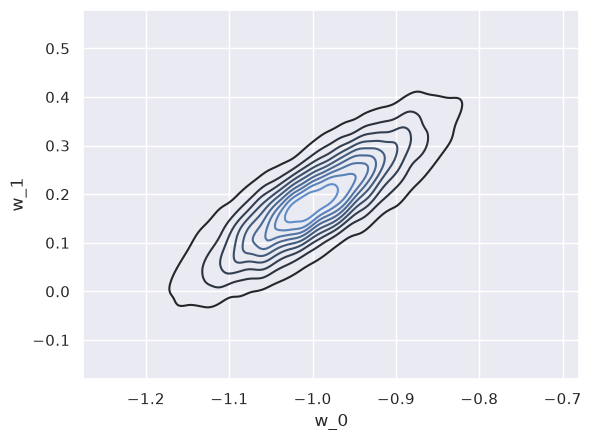

In [20]:
samples = model.betas.posterior_sample(n=10000)
sns.kdeplot(
    x=samples[:, 0, 0],
    y=samples[:, 1, 0],
    cmap=sns.dark_palette("#69d", as_cmap=True),
)
plt.xlabel("w_0")
plt.ylabel("w_1")
plt.show()

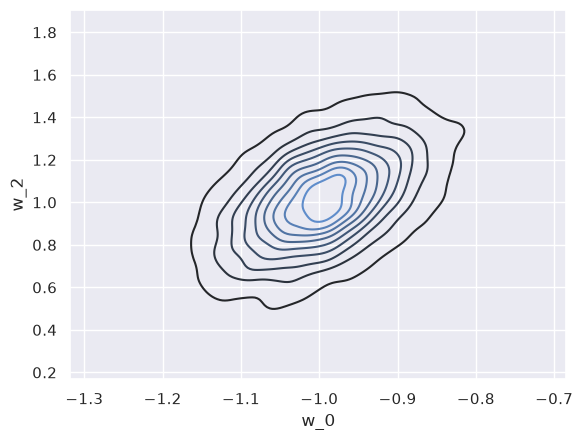

In [21]:
samples = model.betas.posterior_sample(n=10000)
sns.kdeplot(
    x=samples[:, 0, 0],
    y=samples[:, 2, 0],
    cmap=sns.dark_palette("#69d", as_cmap=True),
)
plt.xlabel("w_0")
plt.ylabel("w_2")
plt.show()